# Week 4 - Normal Location-Scale Family

**Companion to**: `notes/w04_stat101_normal_loc_scale.md`

## Goals

1. Review symmetry properties of the standard normal $Z \sim \mathcal{N}(0,1)$.
2. Implement location-scale transforms $X = \mu + \sigma Z$ and standardization.
3. Verify CDF/PDF identities and variance rules numerically.
4. Connect theory to simulation with the 68-95-99.7 rule.



---

## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=4)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12


---

## Section 1: Standard Normal Recap and Symmetry

For $Z \sim \mathcal{N}(0,1)$:

$$
\mathbb{E}[Z] = 0, \quad \mathbb{E}[Z^2] = 1, \quad \mathbb{E}[Z^3] = 0.
$$

The third moment is zero because $z^3\phi(z)$ is an odd function over $(-\infty, \infty)$.



### TODO 1.1: Implement Gaussian PDF and analytic odd-moment integrand


In [2]:
def gaussian_pdf(x, mu=0.0, sigma=1.0):
    """Gaussian PDF p(x) for N(mu, sigma^2)."""
    # TODO: Implement p(x) = 1/(sigma*sqrt(2*pi)) * exp(-(x-mu)^2/(2*sigma^2))
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))


def odd_moment_integrand(z):
    """Integrand for E[Z^3] under N(0,1): z^3 * phi(z)."""
    # TODO: Return z**3 * gaussian_pdf(z)
    return z**3 * gaussian_pdf(z)


In [3]:
z_grid = np.linspace(-4, 4, 801)

# Symmetry check for the standard normal density: phi(z) == phi(-z)
# This cell should pass once gaussian_pdf is implemented.
if callable(gaussian_pdf):
    left = gaussian_pdf(z_grid)
    right = gaussian_pdf(-z_grid)
    if isinstance(left, np.ndarray) and isinstance(right, np.ndarray):
        max_sym_err = np.max(np.abs(left - right))
        print(f'Max symmetry error for phi(z) vs phi(-z): {max_sym_err:.2e}')

# Monte Carlo estimates for moments
z_samples = rng.normal(loc=0.0, scale=1.0, size=200_000)
print(f'Estimated E[Z]   = {np.mean(z_samples): .4f}')
print(f'Estimated E[Z^2] = {np.mean(z_samples**2): .4f}')
print(f'Estimated E[Z^3] = {np.mean(z_samples**3): .4f}')


Max symmetry error for phi(z) vs phi(-z): 0.00e+00
Estimated E[Z]   =  0.0041
Estimated E[Z^2] =  0.9992
Estimated E[Z^3] =  0.0102


In [4]:
# Optional checkpoint (uncomment after TODO 1.1 is done):
z_grid = np.linspace(-4, 4, 801)
max_sym_err = np.max(np.abs(gaussian_pdf(z_grid) - gaussian_pdf(-z_grid)))
assert max_sym_err < 1e-12, f'Symmetry error too large: {max_sym_err:.2e}'
print('Checkpoint passed: Gaussian PDF symmetry holds numerically.')


Checkpoint passed: Gaussian PDF symmetry holds numerically.


---

## Section 2: Location-Scale Transform and Standardization

If $Z \sim \mathcal{N}(0,1)$ and

$$
X = \mu + \sigma Z,
$$

then $X \sim \mathcal{N}(\mu, \sigma^2)$.

Conversely, if $X \sim \mathcal{N}(\mu, \sigma^2)$, then

$$
\frac{X - \mu}{\sigma} \sim \mathcal{N}(0,1).
$$



### TODO 2.1: Implement transform helpers


In [5]:
def from_standard(z, mu, sigma):
    """Map Z ~ N(0,1) to X ~ N(mu, sigma^2)."""
    # TODO: return mu + sigma * z
    return mu + sigma * z


def to_standard(x, mu, sigma):
    """Map X ~ N(mu, sigma^2) back to Z ~ N(0,1)."""
    # TODO: return (x - mu) / sigma
    return (x - mu) / sigma


In [6]:
mu, sigma = 2.0, 1.5
z = rng.normal(size=200_000)

# This section verifies mean/variance behavior after transformation.
x = from_standard(z, mu, sigma)
print(f'Empirical mean(X): {np.mean(x):.4f} (theory: {mu:.4f})')
print(f'Empirical var(X):  {np.var(x):.4f} (theory: {sigma**2:.4f})')

# Standardize back
z_back = to_standard(x, mu, sigma)
print(f'Empirical mean(Z_back): {np.mean(z_back):.4f} (theory: 0.0000)')
print(f'Empirical var(Z_back):  {np.var(z_back):.4f} (theory: 1.0000)')


Empirical mean(X): 1.9960 (theory: 2.0000)
Empirical var(X):  2.2494 (theory: 2.2500)
Empirical mean(Z_back): -0.0027 (theory: 0.0000)
Empirical var(Z_back):  0.9997 (theory: 1.0000)


In [7]:
# Optional checkpoint (uncomment after TODO 2.1 is done):
mu, sigma = 2.0, 1.5
z = rng.normal(size=200_000)
x = from_standard(z, mu, sigma)
z_back = to_standard(x, mu, sigma)
assert abs(np.mean(x) - mu) < 0.02
assert abs(np.var(x) - sigma**2) < 0.05
assert abs(np.mean(z_back)) < 0.02
assert abs(np.var(z_back) - 1.0) < 0.02
print('Checkpoint passed: location-scale transform verified empirically.')


Checkpoint passed: location-scale transform verified empirically.


### Visual Diagnostic

The transformed distribution should match a Normal curve centered at $\mu$ with spread $\sigma$.



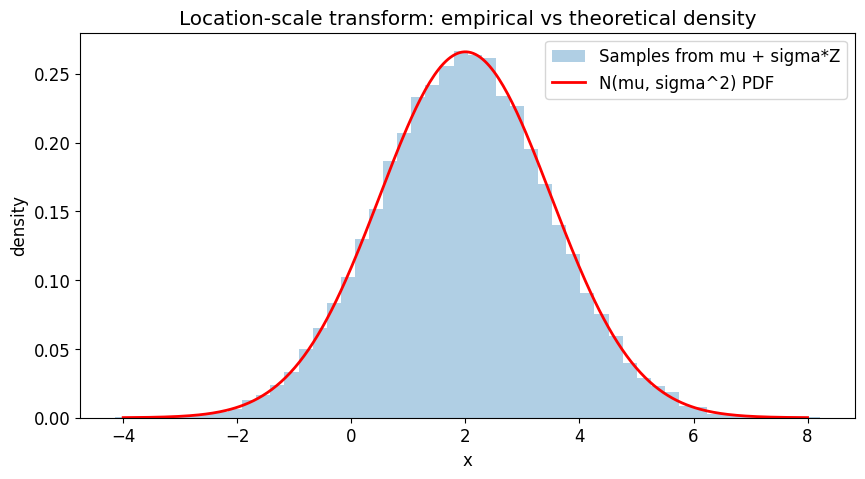

In [8]:
mu, sigma = 2.0, 1.5
z = rng.normal(size=20_000)
x = mu + sigma * z  # direct form so this plot runs even before TODO 2.1 is solved

fig, ax = plt.subplots()
ax.hist(x, bins=50, density=True, alpha=0.35, label='Samples from mu + sigma*Z')
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(xs, stats.norm.pdf(xs, loc=mu, scale=sigma), 'r-', lw=2, label='N(mu, sigma^2) PDF')
ax.set_title('Location-scale transform: empirical vs theoretical density')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
plt.show()


---

## Section 3: CDF and PDF Identities from Standardization

For $X \sim \mathcal{N}(\mu, \sigma^2)$:

$$
F_X(x) = \Phi\left(\frac{x-\mu}{\sigma}\right),
$$

and

$$
f_X(x) = \frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right).
$$



### TODO 3.1: Verify CDF and PDF formulas numerically


In [11]:
mu, sigma = -1.0, 2.5
x_grid = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

# TODO: fill in these arrays using the formulas above
cdf_via_standard = stats.norm.cdf(to_standard(x_grid, mu=mu, sigma=sigma))
cdf_direct = stats.norm.cdf(x_grid, loc=mu, scale=sigma)
pdf_via_formula = gaussian_pdf(x_grid, mu=mu, sigma=sigma)
pdf_direct = stats.norm.pdf(x_grid, loc=mu, scale=sigma)

# After filling TODOs, compare with max absolute error
cdf_err = np.max(np.abs(cdf_via_standard - cdf_direct))
pdf_err = np.max(np.abs(pdf_via_formula - pdf_direct))
print(f'Max CDF error: {cdf_err:.2e}')
print(f'Max PDF error: {pdf_err:.2e}')


Max CDF error: 0.00e+00
Max PDF error: 2.78e-17


In [12]:
# Reference implementation for self-check (read after you attempt TODO 3.1)
mu, sigma = -1.0, 2.5
x_grid = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

cdf_via_standard_ref = stats.norm.cdf((x_grid - mu) / sigma)
cdf_direct_ref = stats.norm.cdf(x_grid, loc=mu, scale=sigma)
pdf_via_formula_ref = gaussian_pdf(x_grid, mu=mu, sigma=sigma) if 'gaussian_pdf' in globals() else None
pdf_direct_ref = stats.norm.pdf(x_grid, loc=mu, scale=sigma)

if isinstance(pdf_via_formula_ref, np.ndarray):
    cdf_err_ref = np.max(np.abs(cdf_via_standard_ref - cdf_direct_ref))
    pdf_err_ref = np.max(np.abs(pdf_via_formula_ref - pdf_direct_ref))
    print(f'Reference max CDF error: {cdf_err_ref:.2e}')
    print(f'Reference max PDF error: {pdf_err_ref:.2e}')


Reference max CDF error: 0.00e+00
Reference max PDF error: 2.78e-17


---

## Section 4: Sums and Differences of Independent Normals

If

$$
X_1 \sim \mathcal{N}(\mu_1, \sigma_1^2), \quad
X_2 \sim \mathcal{N}(\mu_2, \sigma_2^2), \quad
X_1 \perp X_2,
$$

then

$$
X_1 + X_2 \sim \mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2),
$$

$$
X_1 - X_2 \sim \mathcal{N}(\mu_1 - \mu_2, \sigma_1^2 + \sigma_2^2).
$$



### TODO 4.1: Simulate and compare empirical moments with theory


In [13]:
mu1, sigma1 = 1.0, 0.8
mu2, sigma2 = -0.5, 1.3
n = 300_000

x1 = rng.normal(loc=mu1, scale=sigma1, size=n)
x2 = rng.normal(loc=mu2, scale=sigma2, size=n)

# TODO: define y_sum and y_diff
y_sum = x1 + x2
y_diff = x1 - x2

# TODO: print empirical mean/variance for y_sum and y_diff
# and compare with theory
mean_sum_theory = mu1 + mu2
var_sum_theory = sigma1**2 + sigma2**2
mean_diff_theory = mu1 - mu2
var_diff_theory = sigma1**2 + sigma2**2

print(f'X1 + X2 mean: empirical={np.mean(y_sum):.4f}, theory={mean_sum_theory:.4f}')
print(f'X1 + X2 var : empirical={np.var(y_sum):.4f}, theory={var_sum_theory:.4f}')
print(f'X1 - X2 mean: empirical={np.mean(y_diff):.4f}, theory={mean_diff_theory:.4f}')
print(f'X1 - X2 var : empirical={np.var(y_diff):.4f}, theory={var_diff_theory:.4f}')


X1 + X2 mean: empirical=0.5047, theory=0.5000
X1 + X2 var : empirical=2.3267, theory=2.3300
X1 - X2 mean: empirical=1.4953, theory=1.5000
X1 - X2 var : empirical=2.3265, theory=2.3300


In [14]:
# Reference values for quick checking
mu1, sigma1 = 1.0, 0.8
mu2, sigma2 = -0.5, 1.3

mean_sum_theory = mu1 + mu2
var_sum_theory = sigma1**2 + sigma2**2
mean_diff_theory = mu1 - mu2
var_diff_theory = sigma1**2 + sigma2**2

print('Theory for X1 + X2:', (mean_sum_theory, var_sum_theory))
print('Theory for X1 - X2:', (mean_diff_theory, var_diff_theory))


Theory for X1 + X2: (0.5, 2.33)
Theory for X1 - X2: (1.5, 2.33)


---

## Section 5: 68-95-99.7 Rule (Empirical Check)

For $X \sim \mathcal{N}(\mu, \sigma^2)$, approximately:

- $P(|X-\mu| \leq \sigma) \\approx 0.68$
- $P(|X-\mu| \leq 2\sigma) \\approx 0.95$
- $P(|X-\mu| \leq 3\sigma) \\approx 0.997$



### TODO 5.1: Estimate the three probabilities with simulation


In [15]:
mu, sigma = 3.0, 2.0
x = rng.normal(loc=mu, scale=sigma, size=500_000)

# TODO: compute p1, p2, p3
p1 = np.mean(np.abs(x - mu) <= sigma)
p2 = np.mean(np.abs(x - mu) <= 2*sigma)
p3 = np.mean(np.abs(x - mu) <= 3*sigma)

# TODO: print estimated values and compare against (0.68, 0.95, 0.997)
print(f'p1: {p1:.4f}, p2: {p2:.4f}, p3: {p3:.4f}')
print('Theoretical values: 0.68, 0.95, 0.997')



p1: 0.6825, p2: 0.9548, p3: 0.9971
Theoretical values: 0.68, 0.95, 0.997


In [16]:
# Optional checkpoint (uncomment after TODO 5.1)
targets = np.array([0.68, 0.95, 0.997])
est = np.array([p1, p2, p3])
err = np.abs(est - targets)
assert np.all(err < 0.01), f'Rule-of-thumb mismatch: errors={err}'
print('Checkpoint passed: empirical 68-95-99.7 values are close to theory.')


Checkpoint passed: empirical 68-95-99.7 values are close to theory.


---

## Observation and Pitfall

### Observation

Location ($\mu$) shifts the distribution horizontally, and scale ($\sigma$) stretches or compresses it.

### Common Pitfall

Do not forget that variance scales with $\sigma^2$, not $\sigma$.

### Optional Extension

Repeat Section 4 with correlated normals and inspect how covariance changes the variance of sums.



---

## Done

You now have a complete computational walkthrough for the normal location-scale family.

**Next**: connect these transformations to forward and reverse diffusion parameterizations.
